In [2]:
import sqlite3
import pandas as pd

In [3]:
# First we will import the data into the data frame 

df = pd.read_csv('AI_Impact_on_Health_Dataset_5000_Enhanced.csv') 
print(df.head(20)) # using head to not flood all data in the notebook 

    Participant_ID  Age Age_Group  Gender Chronic_Condition   BMI  \
0                1   56     56-65  Female                No  22.2   
1                2   69     66-79    Male                No  24.8   
2                3   46     46-55  Female                No  23.1   
3                4   32     26-35  Female               Yes  24.9   
4                5   60     56-65    Male                No  30.4   
5                6   25     18-25  Female                No  32.1   
6                7   78     66-79    Male               Yes  26.5   
7                8   38     36-45  Female                No  30.3   
8                9   56     56-65  Female               Yes  23.4   
9               10   75     66-79  Female                No  22.5   
10              11   36     36-45  Female               Yes  24.7   
11              12   40     36-45  Female               Yes  23.8   
12              13   28     26-35    Male                No  27.7   
13              14   28     26-35 

# INTRODUCTION

* This dataset analyzes the impact of AI on people's lives, with a primary focus on health and lifestyle.
* It compares individuals' health conditions before and after the adoption of AI.
* The dataset includes information such as age, BMI, and the amount of time each person spends using AI on a daily or weekly basis.
* Some columns contain negative values, which will be examined and discussed later in the analysis.
* Finally, the dataset provides a life risk rating for each individual, enabling us to analyze how AI usage may be associated with overall health risk.


# Roadmap for the Analysis

* **Checking Data Quality**

  * Identify missing values and examine the dataset's statistical summary.

* **Data Cleaning**

  * Handle missing values, remove inconsistencies, and prepare the data for analysis.

* **Data Extraction Using SQL and Pandas**

  * Use SQL queries and Pandas operations to extract meaningful insights from the dataset.

* **Correlation Analysis**

  * Analyze relationships between numerical variables to identify significant patterns.

* **Data Visualization**

  * Create and interpret graphs to clearly explain trends, distributions, and relationships within the data.

* **Final Verdict**

  * Summarize the key findings, present actionable insights, and provide conclusions based on the analysis.


In [4]:
# Checking all o the null values and data types in data 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level                      5000 no

In [5]:
# Theere is no null values or any wrong data type in the whole 5k input of data so now we will recheck the null values using isnull command
print(df.isnull().sum())

Participant_ID                        0
Age                                   0
Age_Group                             0
Gender                                0
Chronic_Condition                     0
BMI                                   0
BMI_Category                          0
AI_Tool_Type                          0
AI_Health_App_Usage_Hours_Per_Week    0
AI_Usage_Level                        0
Exercise_Hours_Per_Week               0
Exercise_Level                        0
Total_Engagement_Hours_Per_Week       0
Health_Score_Before_AI                0
Health_Score_After_AI                 0
Improvement                           0
Improvement_Percentage                0
Improvement_Category                  0
Improvement_Per_AI_Hour               0
Satisfaction_Score                    0
Satisfaction_Level                    0
Risk_Category                         0
dtype: int64


In [6]:
# It is confirmed now so we will use the describe function to get the statatics of the whole data 
print(df.describe())

       Participant_ID          Age         BMI  \
count     5000.000000  5000.000000  5000.00000   
mean      2500.500000    48.805600    25.01756   
std       1443.520003    17.906991     3.98090   
min          1.000000    18.000000    10.60000   
25%       1250.750000    34.000000    22.40000   
50%       2500.500000    49.000000    25.05000   
75%       3750.250000    64.000000    27.70000   
max       5000.000000    79.000000    38.60000   

       AI_Health_App_Usage_Hours_Per_Week  Exercise_Hours_Per_Week  \
count                         5000.000000              5000.000000   
mean                            10.235600                 7.047000   
std                              6.016389                 4.299033   
min                              0.000000                 0.000000   
25%                              5.000000                 3.000000   
50%                             10.500000                 7.000000   
75%                             15.000000                11

### Statistical Summary

* The **average age** of individuals in the dataset is **48 years**.
* The **average BMI** is **25**, which falls within the **overweight** category. The minimum recorded BMI is **10**, indicating the presence of extreme or potentially unrealistic values that may require further investigation.
* On average, individuals use **AI applications for 10 hours per week**.
* The **average exercise time while using AI applications** is **7 hours per week**.
* The **average health score before using AI** is **64**, while the **average health score after using AI** increases to **71**, indicating an overall improvement in health.
* The **average health improvement score** is **7 points**. However, the minimum value is **negative**, suggesting that AI usage had a negative impact on the health of some individuals.
* A similar trend is observed in the **health improvement percentage**, where negative values indicate that some participants experienced a decline in their health after using AI.
* The **average health improvement per hour of AI usage** is **1 point per hour**. However, the minimum value is also negative, showing that increased AI usage did not benefit every individual.
* Finally, the **average satisfaction score** is **5**, indicating a moderate level of satisfaction among users.


Now we will use sql to get the extra info since there is nothing to clean 

# SQL

In [7]:
# Connecting and setting u cursor and sql 
conn = sqlite3.connect('ai_tool.db')
df.to_sql('ai_data' , conn , index = False , if_exists = 'replace')

5000

In [8]:
# With the help of sql we will find the answers of survey insights questions 

# QUE 1 - Which ai tool is used the most ?
# solution - 
query = 'SELECT "AI_Tool_Type" , AVG("AI_Health_App_Usage_Hours_Per_Week") as AVG_AI_USE FROM  ai_data GROUP BY AI_Tool_Type ORDER BY AVG_AI_USE DESC LIMIT 3 '
print(pd.read_sql_query(query,conn))

# usig these prints to improve the readablity of the outputs of code which reduces chances of mistakes
print('--'*90)

# QUE 2 - AGE AND THEIR AVERAGE USAGE LEVEL ONLY TOP 1
# solution 
query2 = 'SELECT "AI_Usage_Level" , AVG("Age") as avg_age FROM ai_data GROUP BY AI_Usage_level '
print(pd.read_sql_query(query2,conn))

print('--'*90)

# que 3 - Number of peoples with less than 0 improvement
# solution - 
query3 = 'SELECT  "improvement" FROM ai_data WHERE improvement < 0 '
print('THE NUMBER OF PEOPLE WITH THE IMPROVEMENT LESS THAN 0 ARE : ',len(pd.read_sql_query(query3,conn)))
# NOW IN PERCENTAGE 
print("NUMBER OF PEOPLE LESS THAN 0 IMPROVEMENT IN PERCENTAGE :",(968/5000)*100,"%")

print('--'*90)

# QUE4 = AVERAGE AGE OF PEOPLE IN RISK FROM HIGH TO LOW
# soution -
query4 = 'SELECT "Risk_Category" , AVG("Age") as avg_age FROM ai_data GROUP BY Risk_Category'
print(pd.read_sql_query(query4,conn))

print('--'*90)

# QUE 5 - Show the average ai usage of people who have negative improvement 
# solution - 
query5 = 'SELECT "improvement" , AVG(" AI_Health_App_Usage_Hours_Per_Week")  as avg_usage FROM ai_data  WHERE improvement < 0 GROUP BY improvement '
print(pd.read_sql_query(query5,conn))

           AI_Tool_Type  AVG_AI_USE
0  Diagnostic Assistant   10.398279
1          Telemedicine   10.323794
2       Fitness Tracker   10.151420
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  AI_Usage_Level    avg_age
0           High  49.142776
1            Low  48.327478
2         Medium  48.909366
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
THE NUMBER OF PEOPLE WITH THE IMPROVEMENT LESS THAN 0 ARE :  968
NUMBER OF PEOPLE LESS THAN 0 IMPROVEMENT IN PERCENTAGE : 19.36 %
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  Risk_Category    avg_age
0          High  60.731707
1           Low  

# Analysis Summary

The following analysis answers the business questions defined earlier. Below is a summary of the key findings and their implications:

* **Query 1:** The three most frequently used AI tools, based on average weekly usage, are:

  1. **Diagnostic Assistant** – **10.40 hours/week**
  2. **Telemedicine** – **10.32 hours/week**
  3. **Fitness Tracker** – **10.15 hours/week**

  These tools have the highest average usage, indicating they are the most commonly adopted AI solutions among users.

* **Query 2:** The average age of users across the **High**, **Medium**, and **Low** AI usage groups is between **48 and 49 years**. This suggests that individuals in this age range are the primary users of AI applications in the dataset.

* **Query 3:** A total of **968 individuals (19.36% of the dataset)** experienced a **negative health improvement score** despite being included in the study. This indicates that AI did not produce positive outcomes for every participant.

* **Query 4:** Individuals with the **highest life risk** have an average age of **68 years**, while those with the **lowest life risk** have an average age of **44 years**. Across all risk categories, the overall average age is approximately **51 years**.

* **Query 5:** The analysis shows that individuals with **negative health improvement** had **little to no AI usage**. This suggests that the negative outcomes cannot be directly attributed to AI usage, as these individuals were not actively using AI applications.


# PANDAS 

In [9]:
# we will mainly use panda for the value counts in data 

In [10]:
# first we will check the number of ai tools
ai_t = df['AI_Tool_Type'].value_counts()

# now we will check the ages above 50
above_50 = df['Age'].where(df['Age'] > 50)

print(df['Improvement_Category'].value_counts())

print('--'*90)

print(df['Risk_Category'].value_counts())

print('--'*90)

print('PEOPLE WITH  AGE ARE MORE THAN 50 ARE : ',len(above_50.dropna()))

print('--'*90)

print(ai_t)

Improvement_Category
Improved           1940
Highly Improved    1892
Declined            968
No Change           200
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Risk_Category
Low       2410
Medium    2180
High       410
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
PEOPLE WITH  AGE ARE MORE THAN 50 ARE :  2375
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AI_Tool_Type
Diagnostic Assistant    1278
Fitness Tracker         1268
Mental Health App       1231
Telemedicine            1223
Name: count, dtype: int64


# Pandas Analysis Summary

* The Pandas analysis shows that **1,940 individuals experienced an improvement** in their health, while **1,892 individuals showed a high level of improvement**. However, **968 individuals experienced a decline**, which is consistent with the findings obtained from the SQL analysis.

* A total of **410 individuals** fall into the **High Risk** category.

* There are **2,375 individuals aged over 50** who actively use AI applications. This indicates that AI tools are being adopted by older adults as well, suggesting that their interfaces and overall user experience are accessible and easy to understand.

* The usage of different AI tools is **fairly balanced**. The difference in the number of users between the most and least used AI tools is only **50–60 users**, indicating that no single AI tool overwhelmingly dominates user adoption.


# PLOTTING 

In [11]:
# First we willl import essential plugins 
import matplotlib.pyplot as plt

import seaborn as sns 
sns.set_style("darkgrid")

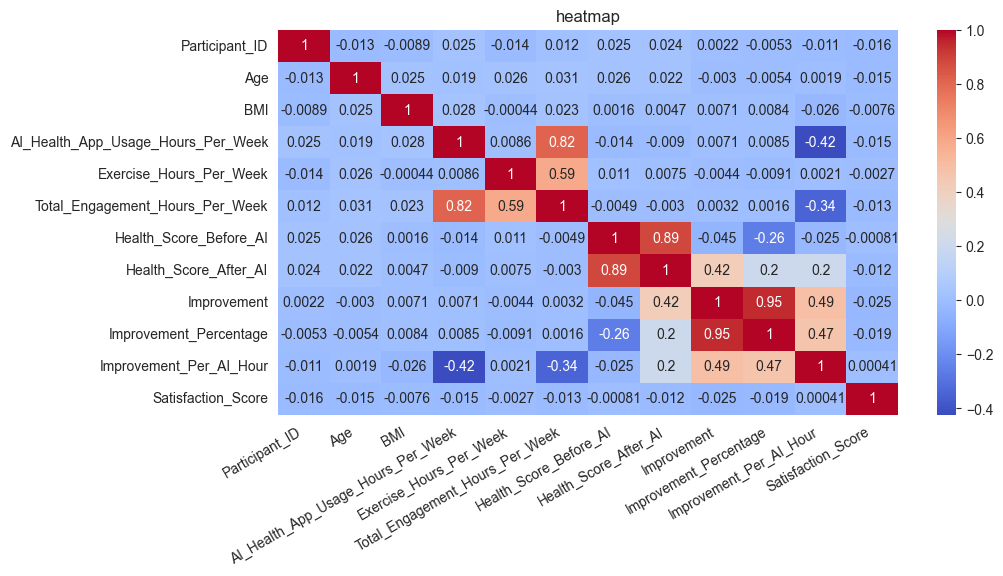

In [18]:
# first we will check the correlation by using the heatmap 
corr = df.corr(numeric_only = True)

plt.figure(figsize = (10,5))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('heatmap')
plt.xticks(rotation = 390 , ha = 'right')
plt.show()

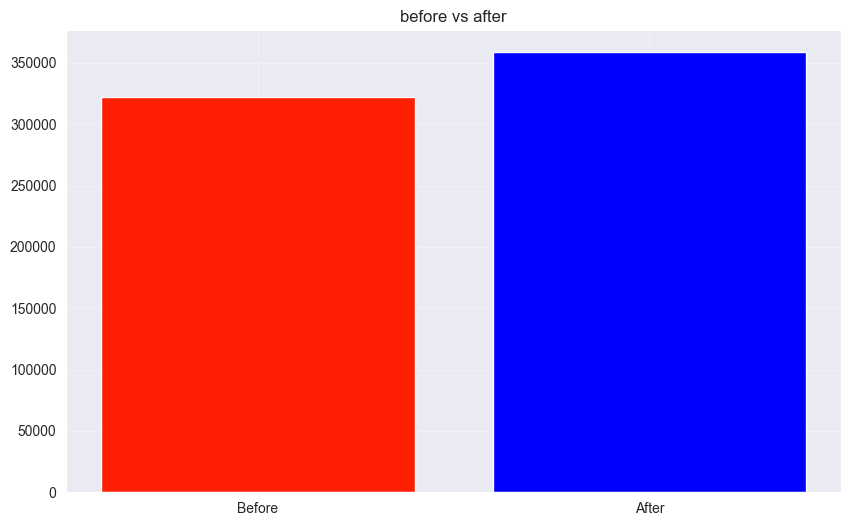

In [13]:
before = df['Health_Score_Before_AI'].sum()
after = df['Health_Score_After_AI'].sum()

plt.figure(figsize =(10,6))
plt.bar('Before' , before , color = '#ff2003')
plt.bar('After',after, color = 'blue')
plt.title('before vs after')
plt.grid(True,alpha = 0.3)
plt.show()

THIS SHOWS THAT BEFORE AND AFTER ARE REALLY IMPROVING 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_6252\3720780915.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df , x = 'AI_Tool_Type' , palette = 'coolwarm')


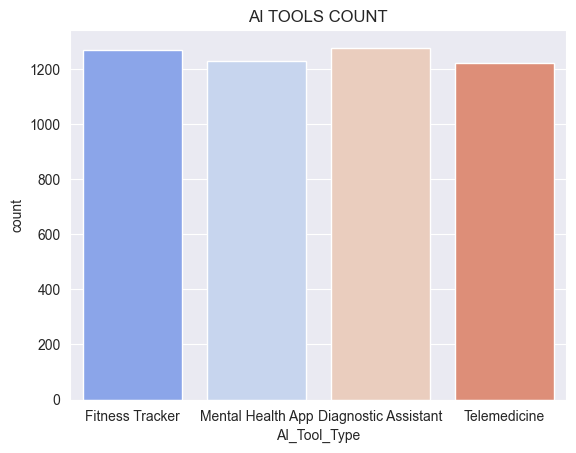

In [14]:
sns.countplot(data = df , x = 'AI_Tool_Type' , palette = 'coolwarm')
plt.title('AI TOOLS COUNT')
plt.show()

This graphs shows that the diagnostic have the highest usage i said earliar

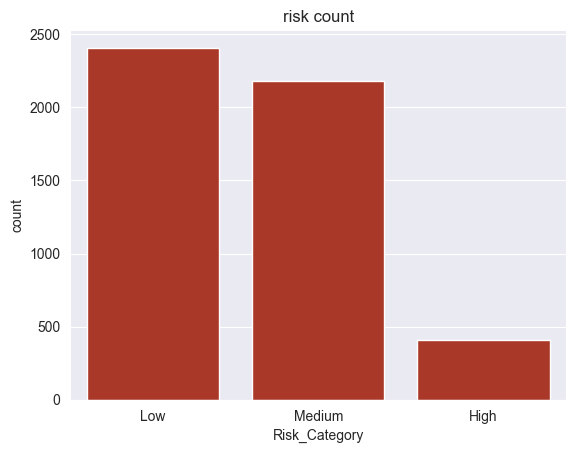

In [15]:
sns.countplot(data = df , x = 'Risk_Category' , color = '#bf2713')
plt.title('risk count')
plt.show()

This graphs is very obsious 

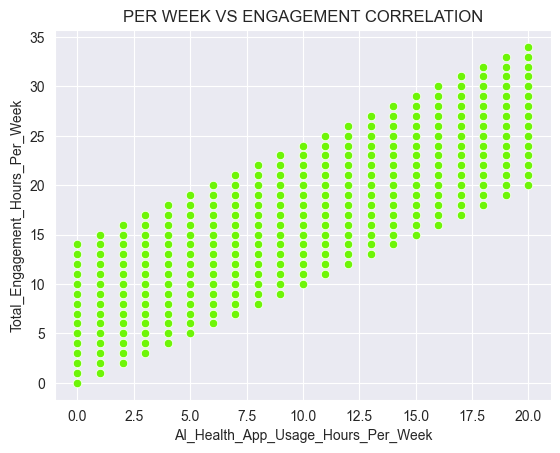

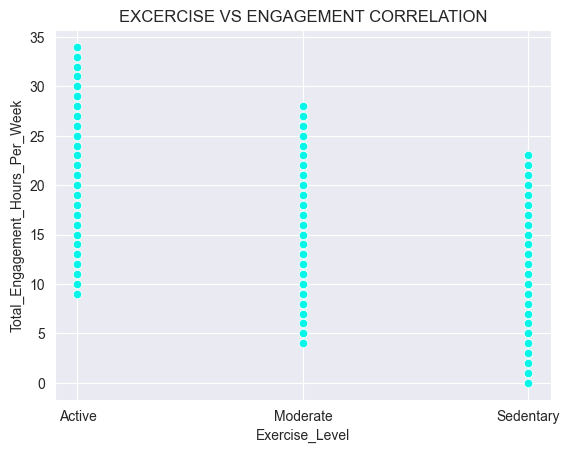

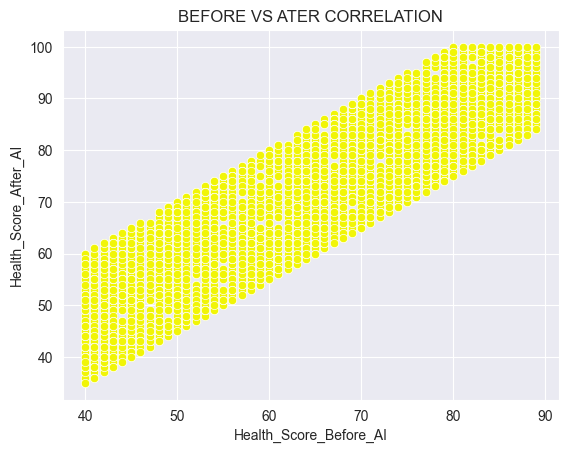

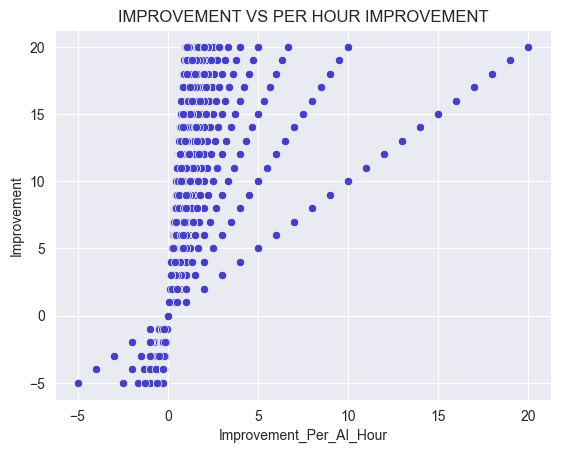

In [16]:
sns.scatterplot(data = df , x = 'AI_Health_App_Usage_Hours_Per_Week' , y = 'Total_Engagement_Hours_Per_Week' , color = '#6ef507')
plt.title('PER WEEK VS ENGAGEMENT CORRELATION')
plt.show()

sns.scatterplot(data = df , x = 'Exercise_Level' , y = 'Total_Engagement_Hours_Per_Week' , color = '#07f5e9')
plt.title('EXCERCISE VS ENGAGEMENT CORRELATION')
plt.show()


sns.scatterplot(data = df , x = 'Health_Score_Before_AI' , y = 'Health_Score_After_AI' , color = '#f1f507')
plt.title('BEFORE VS ATER CORRELATION')
plt.show()

sns.scatterplot(data = df , x = 'Improvement_Per_AI_Hour' , y = 'Improvement' , color = '#4440c7')
plt.title('IMPROVEMENT VS PER HOUR IMPROVEMENT')
plt.show()

### Correlation Analysis

Most of the correlation graphs show reasonable and meaningful relationships between the variables. However, there is one important exception: the **Health Score Before AI vs. Health Score After AI** graph.

The graph displays an almost perfect positive correlation, but this result should **not** be interpreted as evidence that the two variables directly depend on each other. In reality, the **health score after AI usage is influenced by multiple factors**, such as AI usage, exercise, lifestyle, and other health-related variables—not solely by the initial health score.

Therefore, while the strong correlation is mathematically correct, it can be **misleading** if interpreted as a causal relationship. The graph indicates that individuals with higher health scores before AI generally also have higher scores after AI, but it **does not prove that the "before" score causes the "after" score**.


# Final Verdict

This analysis provides a comprehensive overview of how AI usage is associated with individuals' health and lifestyle. After cleaning the dataset and analyzing it using both **SQL** and **Pandas**, several meaningful insights were identified.

The results show that the **average health score increased from 64 to 71** after AI adoption, indicating an overall positive impact. Most individuals experienced either moderate or significant improvement in their health, while **968 people (19.36%)** showed a decline. Further analysis revealed that many of these individuals had **little or no AI usage**, suggesting that their negative outcomes cannot be directly attributed to AI itself.

The most widely used AI tools are **Diagnostic Assistant**, **Telemedicine**, and **Fitness Tracker**, with all three showing very similar usage levels. This indicates that users are adopting different types of AI tools rather than relying on a single application.

The analysis also shows that **people aged 48–49** are the most active AI users, while **2,375 users are over the age of 50**. This suggests that AI applications are accessible to older adults and that their user interfaces are generally easy to understand.

Correlation analysis identified several meaningful relationships, but it also highlighted the importance of interpreting correlations carefully. For example, the strong correlation between **Health Score Before AI** and **Health Score After AI** should not be interpreted as a causal relationship, since the post-AI health score is influenced by multiple factors.

### Conclusion

Overall, the dataset suggests that AI has a **generally positive association with health outcomes** for most users. However, AI is **not a guaranteed solution** for everyone, as individual results vary depending on usage patterns and other personal factors. Any conclusions drawn from this dataset should be interpreted as **associations rather than proof of causation**, and additional real-world factors should be considered before making business or healthcare decisions.

### Business Recommendation:
"Companies should prioritize investment in Diagnostic Assistant tools for users above 50, as this group shows the highest engagement and risk category. For users with low AI usage (under 5 hours/week), implement engagement nudges—since they show zero improvement, increasing their usage could unlock significant health gains."    
